# Imports and Defaults

In [1]:
import math
import pandas as pd
import seaborn as sns
import numpy as np

In [2]:
sns.set_theme(style="whitegrid")
seq_len = 2048

# Data

In [3]:
greedy = [
    0.0034, 0.0038, 0.0004, 0.0015, 0.0016, 0.0026, 0.0044, 0.0020, 0.0018, 0.0033, 0.0038, 0.0006, 0.0027, 0.0004, 0.0015, 0.0015, 0.0035, 0.0030, 0.0008, 0.0006, 0.0006, 0.0007, 0.0008, 0.0013, 0.0012, 0.0012, 0.0040, 0.0014, 0.0033, 0.0000, 0.0000, 0.0023, 0.0013, 0.0009, 0.0006, 0.0039, 0.0009, 0.0024, 0.0014, 0.0050, 0.0004, 0.0032, 0.0023, 0.0019, 0.0017, 0.0017, 0.0010, 0.0012, 0.0020, 0.0006, 0.0032, 0.0007, 0.0030, 0.0032, 0.0030, 0.0010, 0.0007, 0.0056, 0.0026, 0.0041, 0.0037, 0.0019, 0.0008, 0.0028, 0.0030, 0.0023, 0.0028, 0.0016, 0.0006, 0.0039, 0.0016, 0.0042, 0.0017, 0.0039, 0.0025, 0.0041, 0.0001, 0.0044, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0001, 0.0001, 0.0002, 0.0005, 0.0012, 0.0009, 0.0031, 0.0012, 0.0011, 0.0040, 0.0032, 0.0015, 0.0026, 0.0022, 0.0010, 0.0004, 0.0006, 0.0000, 0.0014, 0.0041, 0.0001, 0.0009, 0.0007, 0.0009, 0.0000, 0.0027, 0.0020, 0.0040, 0.0011, 0.0002, 0.0002, 0.0005, 0.0004, 0.0016, 0.0008, 0.0043, 0.0013, 0.0001, 0.0035, 0.0020, 0.0021, 0.0051, 0.0037, 0.0011, 0.0031, 0.0018, 0.0009, 0.0005, 0.0034, 0.0034, 0.0054, 0.0024, 0.0007, 0.0027, 0.0028, 0.0016, 0.0002, 0.0003, 0.0017, 0.0027, 0.0037, 0.0047, 0.0067, 0.0018, 0.0054, 0.0000, 0.0002, 0.0035, 0.0049, 0.0026, 0.0040, 0.0007, 0.0053, 0.0021, 0.0004, 0.0001, 0.0000, 0.0000, 0.0040, 0.0037, 0.0006, 0.0032, 0.0041, 0.0043, 0.0009, 0.0036, 0.0012, 0.0042, 0.0012, 0.0042, 0.0039, 0.0020, 0.0013, 0.0042, 0.0027, 0.0006, 0.0041, 0.0004, 0.0021, 0.0010, 0.0036, 0.0027, 0.0019, 0.0000, 0.0043, 0.0019, 0.0037, 0.0031, 0.0014, 0.0059, 0.0024, 0.0005, 0.0008, 0.0032, 0.0015, 0.0045, 0.0014, 0.0023, 0.0013, 0.0040, 0.0005, 0.0015, 0.0021, 0.0050, 0.0010, 0.0024, 0.0026, 0.0026, 0.0000, 0.0000, 0.0004, 0.0009, 0.0020, 0.0021, 0.0015, 0.0049, 0.0006, 0.0006, 0.0010, 0.0009, 0.0018, 0.0019, 0.0051, 0.0003, 0.0047, 0.0007, 0.0034, 0.0011, 0.0028, 0.0011, 0.0049, 0.0021, 0.0005, 0.0045, 0.0004, 0.0002, 0.0032, 0.0031, 0.0000, 0.0037, 0.0003, 0.0010, 0.0037, 0.0023, 0.0005, 0.0010, 0.0029, 0.0029, 0.0022, 0.0024, 0.0013, 0.0024, 0.0040, 0.0006, 0.0001, 0.0046, 0.0000, 0.0000, 0.0023, 0.0022, 0.0004, 0.0005, 0.0037, 0.0015, 0.0042, 0.0021, 0.0015, 0.0022, 0.0002, 0.0032, 0.0036, 0.0009, 0.0023, 0.0000, 0.0000, 0.0034, 0.0034, 0.0006, 0.0000, 0.0010, 0.0051, 0.0000, 0.0030, 0.0007, 0.0049, 0.0002, 0.0016, 0.0000, 0.0000, 0.0010, 0.0010, 0.0000, 0.0062, 0.0011, 0.0001, 0.0039, 0.0002, 0.0027, 0.0024, 0.0037, 0.0005, 0.0009, 0.0012, 0.0016, 0.0032, 0.0008, 0.0003, 0.0028, 0.0042, 0.0005, 0.0037, 0.0002, 0.0034, 0.0009, 0.0054, 0.0001, 0.0005, 0.0000, 0.0039, 0.0009, 0.0013, 0.0027, 0.0001, 0.0006, 0.0042, 0.0017, 0.0005, 0.0007, 0.0024, 0.0002, 0.0013, 0.0043, 0.0002, 0.0007, 0.0021, 0.0000, 0.0000, 0.0037, 0.0000, 0.0000, 0.0039, 0.0002, 0.0024, 0.0026, 0.0033, 0.0025, 0.0025, 0.0001, 0.0000, 0.0001, 0.0003, 0.0020, 0.0027, 0.0056, 0.0029, 0.0011, 0.0004, 0.0001, 0.0013, 0.0006, 0.0043, 0.0056, 0.0001, 0.0014, 0.0009, 0.0036, 0.0005, 0.0013, 0.0033, 0.0024, 0.0003, 0.0035, 0.0009, 0.0000, 0.0040, 0.0015, 0.0018, 0.0065, 0.0044, 0.0015, 0.0008, 0.0030, 0.0002, 0.0000, 0.0016, 0.0032, 0.0026, 0.0005, 0.0038, 0.0009, 0.0009, 0.0018, 0.0010, 0.0023, 0.0002, 0.0002, 0.0032, 0.0004, 0.0020, 0.0000, 0.0006, 0.0003, 0.0043, 0.0021, 0.0014, 0.0007, 0.0014, 0.0000, 0.0010, 0.0057, 0.0001, 0.0012, 0.0032, 0.0003, 0.0024, 0.0028, 0.0000, 0.0008, 0.0011, 0.0038, 0.0008, 0.0005, 0.0014, 0.0044, 0.0033, 0.0002, 0.0008, 0.0036, 0.0039, 0.0035, 0.0035, 0.0003, 0.0023, 0.0005, 0.0022, 0.0035, 0.0035, 0.0029, 0.0036, 0.0027, 0.0015, 0.0002, 0.0041, 0.0001, 0.0008, 0.0016, 0.0014, 0.0002, 0.0029, 0.0030, 0.0005, 0.0004, 0.0037, 0.0001, 0.0006, 0.0022, 0.0038, 0.0023, 0.0013, 0.0007, 0.0023, 0.0006, 0.0023, 0.0010, 0.0042, 0.0011, 0.0047, 0.0024, 0.0018, 0.0013, 0.0004, 0.0008, 0.0005, 0.0002, 0.0029, 0.0024, 0.0001, 0.0009, 0.0012, 0.0045, 0.0052, 0.0015, 0.0009, 0.0057, 0.0000, 0.0000, 0.0017, 0.0004, 0.0011, 0.0022, 0.0001, 0.0000, 0.0024, 0.0000, 0.0062, 0.0001, 0.0000, 0.0018, 0.0050, 0.0041, 0.0013, 0.0001, 0.0021, 0.0005, 0.0004, 0.0006, 0.0008, 0.0019, 0.0032, 0.0019, 0.0003, 0.0003, 0.0002, 0.0035, 0.0001, 0.0002, 0.0005, 0.0000, 0.0005, 0.0002, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0043, 0.0032, 0.0031, 0.0006, 0.0069, 0.0005, 0.0007, 0.0034, 0.0006, 0.0035, 0.0064, 0.0011, 0.0015, 0.0047, 0.0002, 0.0006, 0.0014, 0.0037, 0.0004, 0.0012, 0.0018, 0.0028, 0.0005, 0.0000, 0.0013, 0.0005, 0.0007, 0.0047, 0.0000, 0.0000, 0.0040, 0.0024, 0.0000, 0.0040, 0.0005, 0.0004, 0.0029, 0.0000, 0.0029, 0.0000, 0.0050, 0.0000, 0.0015, 0.0025, 0.0013, 0.0025, 0.0048, 0.0010, 0.0038, 0.0000, 0.0019, 0.0048, 0.0013, 0.0000, 0.0007, 0.0038, 0.0006, 0.0020, 0.0027, 0.0000, 0.0004, 0.0021, 0.0032, 0.0036, 0.0000, 0.0000, 0.0019, 0.0002, 0.0007, 0.0014, 0.0021, 0.0013, 0.0027, 0.0007, 0.0036, 0.0000, 0.0000, 0.0029, 0.0011, 0.0029, 0.0001, 0.0000, 0.0037, 0.0011, 0.0033, 0.0017, 0.0049, 0.0018, 0.0030, 0.0011, 0.0036, 0.0013, 0.0032, 0.0044, 0.0003, 0.0004, 0.0011, 0.0018, 0.0044, 0.0054, 0.0004, 0.0027, 0.0011, 0.0052, 0.0005, 0.0001, 0.0017, 0.0017, 0.0054, 0.0003, 0.0035, 0.0001, 0.0008, 0.0052, 0.0004, 0.0013, 0.0017, 0.0029, 0.0034, 0.0030, 0.0018, 0.0029, 0.0015, 0.0016, 0.0020, 0.0006, 0.0021, 0.0010, 0.0006, 0.0006, 0.0010, 0.0016, 0.0023, 0.0013, 0.0009, 0.0005, 0.0049, 0.0012, 0.0018, 0.0012, 0.0025, 0.0003, 0.0000, 0.0039, 0.0042, 0.0014, 0.0009, 0.0010, 0.0030, 0.0024, 0.0033, 0.0018, 0.0006, 0.0009, 0.0010, 0.0004, 0.0023, 0.0033, 0.0050, 0.0024, 0.0003, 0.0004, 0.0023, 0.0004, 0.0016, 0.0033, 0.0026, 0.0022, 0.0004, 0.0023, 0.0013, 0.0027, 0.0004, 0.0014, 0.0007, 0.0010, 0.0006, 0.0011, 0.0038, 0.0005, 0.0023, 0.0009, 0.0017, 0.0034, 0.0046, 0.0000, 0.0000, 0.0006, 0.0021, 0.0001, 0.0000, 0.0042, 0.0016, 0.0004, 0.0009, 0.0003, 0.0010, 0.0024, 0.0006, 0.0000, 0.0014, 0.0016, 0.0007, 0.0016, 0.0016, 0.0040, 0.0004, 0.0022, 0.0028, 0.0046, 0.0028, 0.0007, 0.0052, 0.0022, 0.0052, 0.0014, 0.0000, 0.0055, 0.0022, 0.0007, 0.0002, 0.0007, 0.0016, 0.0010, 0.0038, 0.0003, 0.0018, 0.0001, 0.0036, 0.0005, 0.0009, 0.0020, 0.0038, 0.0022, 0.0001, 0.0037, 0.0000, 0.0000, 0.0004, 0.0019, 0.0032, 0.0004, 0.0006, 0.0008, 0.0012, 0.0024, 0.0008, 0.0047, 0.0024, 0.0046, 0.0042, 0.0015, 0.0015, 0.0038, 0.0007, 0.0035, 0.0038, 0.0005, 0.0022, 0.0013, 0.0029, 0.0000, 0.0000, 0.0032, 0.0016, 0.0000, 0.0002, 0.0051, 0.0022, 0.0039, 0.0000, 0.0000, 0.0038, 0.0010, 0.0001, 0.0028, 0.0042, 0.0001, 0.0035, 0.0029, 0.0001, 0.0022, 0.0027, 0.0000, 0.0018, 0.0035, 0.0003, 0.0014, 0.0000, 0.0000, 0.0006, 0.0038, 0.0008, 0.0010, 0.0002, 0.0038, 0.0001, 0.0031, 0.0000, 0.0033, 0.0004, 0.0039, 0.0005, 0.0025, 0.0023, 0.0002, 0.0000, 0.0038, 0.0054, 0.0000, 0.0001, 0.0001, 0.0045, 0.0020, 0.0001, 0.0002, 0.0007, 0.0000, 0.0008, 0.0023, 0.0032, 0.0001, 0.0050, 0.0001, 0.0004, 0.0037, 0.0001, 0.0002, 0.0008, 0.0018, 0.0034, 0.0012, 0.0025, 0.0000, 0.0020, 0.0018, 0.0000, 0.0014, 0.0048, 0.0006, 0.0002, 0.0007, 0.0008, 0.0008, 0.0000, 0.0032, 0.0014, 0.0015, 0.0022, 0.0010, 0.0037, 0.0000, 0.0008, 0.0052, 0.0001, 0.0000, 0.0006, 0.0000, 0.0025, 0.0002, 0.0039, 0.0006, 0.0006, 0.0009, 0.0026, 0.0007, 0.0022, 0.0012, 0.0027, 0.0003, 0.0003, 0.0013, 0.0002, 0.0006, 0.0020, 0.0008, 0.0025, 0.0014, 0.0028, 0.0007, 0.0022, 0.0018, 0.0021, 0.0042, 0.0019, 0.0020, 0.0004, 0.0043, 0.0017, 0.0006, 0.0023, 0.0034, 0.0024, 0.0007, 0.0004, 0.0042, 0.0001, 0.0001, 0.0022, 0.0000, 0.0008, 0.0030, 0.0005, 0.0013, 0.0001, 0.0001, 0.0006, 0.0062, 0.0014, 0.0012, 0.0000, 0.0043, 0.0004, 0.0017, 0.0049, 0.0004, 0.0006, 0.0042, 0.0003, 0.0005, 0.0024, 0.0006, 0.0027, 0.0029, 0.0000, 0.0010, 0.0011, 0.0004, 0.0013, 0.0024, 0.0022, 0.0045, 0.0010, 0.0017, 0.0011, 0.0011, 0.0060, 0.0018, 0.0002, 0.0021, 0.0034, 0.0018, 0.0051, 0.0009, 0.0053, 0.0042, 0.0022, 0.0050, 0.0039, 0.0003, 0.0000, 0.0006, 0.0000, 0.0000, 0.0000, 0.0000, 0.0008, 0.0005, 0.0007, 0.0025, 0.0029, 0.0002, 0.0008, 0.0014, 0.0002, 0.0030, 0.0017, 0.0022, 0.0000, 0.0018, 0.0018, 0.0022, 0.0009, 0.0008, 0.0019, 0.0003, 0.0004, 0.0016, 0.0017, 0.0006, 0.0009, 0.0014, 0.0024, 0.0002, 0.0010, 0.0010, 0.0006, 0.0046, 0.0014, 0.0012, 0.0055, 0.0037, 0.0034, 0.0021, 0.0016, 0.0034, 0.0003, 0.0017, 0.0033, 0.0012, 0.0001, 0.0017, 0.0025, 0.0038, 0.0001, 0.0001, 0.0057, 0.0009, 0.0006, 0.0038, 0.0017, 0.0023, 0.0029, 0.0031, 0.0007, 0.0032, 0.0052, 0.0003, 0.0037, 0.0036, 0.0045, 0.0039, 0.0013, 0.0010, 0.0013, 0.0019, 0.0011, 0.0035, 0.0009, 0.0023, 0.0020, 0.0000, 0.0027, 0.0004, 0.0042, 0.0028, 0.0038, 0.0002, 0.0005, 0.0017, 0.0017, 0.0031, 0.0028, 0.0008, 0.0028, 0.0017, 0.0006, 0.0008, 0.0030, 0.0008, 0.0003, 0.0012, 0.0008, 0.0022, 0.0050, 0.0028, 0.0022, 0.0000, 0.0019, 0.0033, 0.0052, 0.0029, 0.0000, 0.0010, 0.0015, 0.0009, 0.0003, 0.0021, 0.0002, 0.0017, 0.0001, 0.0025, 0.0000, 0.0000, 0.0046, 0.0030, 0.0000, 0.0001, 0.0016, 0.0035, 0.0020, 0.0017, 0.0021, 0.0020, 0.0017, 0.0015, 0.0025, 0.0005, 0.0007, 0.0009, 0.0016, 0.0046, 0.0001, 0.0000, 0.0006, 0.0006, 0.0028, 0.0019, 0.0011, 0.0017, 0.0022, 0.0020, 0.0028, 0.0007, 0.0045, 0.0000, 0.0007, 0.0007, 0.0015, 0.0016, 0.0016, 0.0045, 0.0024, 0.0068, 0.0021, 0.0019, 0.0019, 0.0012, 0.0038, 0.0021, 0.0051, 0.0002, 0.0037, 0.0013, 0.0006, 0.0029, 0.0049, 0.0005, 0.0019, 0.0008, 0.0034, 0.0001, 0.0008, 0.0048, 0.0012, 0.0001, 0.0012, 0.0048, 0.0043, 0.0053, 0.0003, 0.0006, 0.0013, 0.0027, 0.0035, 0.0019, 0.0011, 0.0022, 0.0009, 0.0006, 0.0009, 0.0030, 0.0001, 0.0008, 0.0029, 0.0019, 0.0012, 0.0045, 0.0000, 0.0007, 0.0024, 0.0003, 0.0034, 0.0048, 0.0001, 0.0006, 0.0007, 0.0031, 0.0030, 0.0001, 0.0023, 0.0027, 0.0052, 0.0002, 0.0010, 0.0016, 0.0024, 0.0033, 0.0021, 0.0020, 0.0012, 0.0002, 0.0014, 0.0011, 0.0044, 0.0000, 0.0000, 0.0008, 0.0009, 0.0015, 0.0008, 0.0031, 0.0000, 0.0000, 0.0017, 0.0010, 0.0013, 0.0036, 0.0007, 0.0023, 0.0026, 0.0012, 0.0027, 0.0001, 0.0011, 0.0018, 0.0025, 0.0013, 0.0043, 0.0037, 0.0005, 0.0026, 0.0043, 0.0002, 0.0051, 0.0007, 0.0029, 0.0008, 0.0011, 0.0001, 0.0000, 0.0053, 0.0015, 0.0000, 0.0000, 0.0026, 0.0033, 0.0030, 0.0000, 0.0000, 0.0025, 0.0033, 0.0023, 0.0026, 0.0026, 0.0012, 0.0008, 0.0003, 0.0009, 0.0026, 0.0000, 0.0000, 0.0024, 0.0010, 0.0021, 0.0013, 0.0035, 0.0013, 0.0015, 0.0010, 0.0031, 0.0021, 0.0006, 0.0023, 0.0031, 0.0003, 0.0000, 0.0043, 0.0002, 0.0006, 0.0036, 0.0000, 0.0006, 0.0029, 0.0018, 0.0020, 0.0004, 0.0000, 0.0055, 0.0028, 0.0034, 0.0001, 0.0003, 0.0023, 0.0001, 0.0002, 0.0011, 0.0001, 0.0000, 0.0063, 0.0001, 0.0042, 0.0008, 0.0029, 0.0053, 0.0000, 0.0005, 0.0002, 0.0044, 0.0005, 0.0003, 0.0014, 0.0001, 0.0000, 0.0020, 0.0040, 0.0000, 0.0000, 0.0008, 0.0006, 0.0044, 0.0021, 0.0019, 0.0039, 0.0012, 0.0001, 0.0033, 0.0017, 0.0008, 0.0040, 0.0007, 0.0007, 0.0002, 0.0033, 0.0001, 0.0009, 0.0000, 0.0063, 0.0002, 0.0015, 0.0050, 0.0004, 0.0010, 0.0006, 0.0013, 0.0011, 0.0000, 0.0064, 0.0003, 0.0005, 0.0014, 0.0033, 0.0016, 0.0017, 0.0002, 0.0010, 0.0033, 0.0009, 0.0018, 0.0004, 0.0009, 0.0024, 0.0009, 0.0016, 0.0004, 0.0014, 0.0005, 0.0009, 0.0003, 0.0022, 0.0007, 0.0038, 0.0015, 0.0030, 0.0021, 0.0040, 0.0021, 0.0013, 0.0005, 0.0030, 0.0001, 0.0016, 0.0002, 0.0049, 0.0001, 0.0003, 0.0025, 0.0027, 0.0011, 0.0012, 0.0027, 0.0009, 0.0002, 0.0006, 0.0000, 0.0000, 0.0041, 0.0038, 0.0001, 0.0034, 0.0001, 0.0001, 0.0001, 0.0001, 0.0016, 0.0036, 0.0044, 0.0013, 0.0033, 0.0004, 0.0025, 0.0051, 0.0027, 0.0009, 0.0020, 0.0020, 0.0003, 0.0026, 0.0005, 0.0025, 0.0046, 0.0018, 0.0008, 0.0001, 0.0002, 0.0017, 0.0037, 0.0018, 0.0057, 0.0001, 0.0000, 0.0004, 0.0004, 0.0019, 0.0002, 0.0015, 0.0007, 0.0000, 0.0006, 0.0006, 0.0023, 0.0034, 0.0020, 0.0001, 0.0024, 0.0009, 0.0010, 0.0024, 0.0013, 0.0012, 0.0005, 0.0010, 0.0020, 0.0013, 0.0047, 0.0001, 0.0006, 0.0005, 0.0003, 0.0033, 0.0035, 0.0000, 0.0040, 0.0025, 0.0017, 0.0000, 0.0012, 0.0014, 0.0009, 0.0000, 0.0012, 0.0038, 0.0027, 0.0005, 0.0018, 0.0015, 0.0008, 0.0039, 0.0024, 0.0038, 0.0035, 0.0009, 0.0027, 0.0026, 0.0017, 0.0016, 0.0002, 0.0045, 0.0003, 0.0005, 0.0015, 0.0012, 0.0046, 0.0001, 0.0029, 0.0002, 0.0018, 0.0028, 0.0007, 0.0044, 0.0003, 0.0005, 0.0042, 0.0008, 0.0016, 0.0020, 0.0009, 0.0029, 0.0000, 0.0000, 0.0023, 0.0023, 0.0011, 0.0000, 0.0027, 0.0014, 0.0044, 0.0017, 0.0038, 0.0027, 0.0015, 0.0014, 0.0015, 0.0006, 0.0009, 0.0020, 0.0031, 0.0000, 0.0014, 0.0026, 0.0023, 0.0034, 0.0022, 0.0031, 0.0016, 0.0007, 0.0014, 0.0003, 0.0004, 0.0000, 0.0031, 0.0015, 0.0014, 0.0015, 0.0004, 0.0024, 0.0006, 0.0028, 0.0000, 0.0004, 0.0019, 0.0002, 0.0012, 0.0039, 0.0010, 0.0019, 0.0035, 0.0016, 0.0002, 0.0000, 0.0007, 0.0028, 0.0015, 0.0000, 0.0000, 0.0005, 0.0006, 0.0000, 0.0010, 0.0018, 0.0015, 0.0043, 0.0014, 0.0044, 0.0002, 0.0004, 0.0022, 0.0000, 0.0014, 0.0030, 0.0036, 0.0001, 0.0002, 0.0038, 0.0016, 0.0000, 0.0010, 0.0042, 0.0012, 0.0000, 0.0033, 0.0015, 0.0020, 0.0022, 0.0015, 0.0000, 0.0000, 0.0034, 0.0045, 0.0056, 0.0010, 0.0029, 0.0048, 0.0009, 0.0028, 0.0008, 0.0026, 0.0045, 0.0043, 0.0012, 0.0002, 0.0031, 0.0000, 0.0037, 0.0002, 0.0000, 0.0031, 0.0001, 0.0021, 0.0000, 0.0055, 0.0034, 0.0046, 0.0010, 0.0008, 0.0012, 0.0039, 0.0011, 0.0010, 0.0055, 0.0043, 0.0044, 0.0037, 0.0028, 0.0003, 0.0020, 0.0028, 0.0002, 0.0000, 0.0000, 0.0001, 0.0001, 0.0009, 0.0013, 0.0011, 0.0004, 0.0014, 0.0006, 0.0003, 0.0012, 0.0006, 0.0008, 0.0023, 0.0037, 0.0003, 0.0046, 0.0006, 0.0000, 0.0001, 0.0028, 0.0008, 0.0000, 0.0000, 0.0055, 0.0000, 0.0000, 0.0015, 0.0031, 0.0035, 0.0040, 0.0001, 0.0012, 0.0049, 0.0016, 0.0039, 0.0046, 0.0025, 0.0048, 0.0012, 0.0034, 0.0035, 0.0009, 0.0045, 0.0002, 0.0013, 0.0007, 0.0030, 0.0008, 0.0048, 0.0001, 0.0048, 0.0015, 0.0001, 0.0021, 0.0019, 0.0004, 0.0033, 0.0008, 0.0003, 0.0024, 0.0008, 0.0036, 0.0011, 0.0007, 0.0036, 0.0000, 0.0040, 0.0040, 0.0038, 0.0008, 0.0038, 0.0040, 0.0015, 0.0006, 0.0006, 0.0035, 0.0032, 0.0008, 0.0024, 0.0006, 0.0017, 0.0035, 0.0009, 0.0035, 0.0002, 0.0002, 0.0012, 0.0043, 0.0036, 0.0031, 0.0031, 0.0002, 0.0019, 0.0012, 0.0016, 0.0022, 0.0044, 0.0016, 0.0011, 0.0022, 0.0013, 0.0005, 0.0004, 0.0014, 0.0009, 0.0030, 0.0008, 0.0012, 0.0042, 0.0013, 0.0009, 0.0009, 0.0043, 0.0006, 0.0006, 0.0023, 0.0030, 0.0008, 0.0044, 0.0022, 0.0035, 0.0018, 0.0016, 0.0011, 0.0038, 0.0039, 0.0029, 0.0014, 0.0034, 0.0027, 0.0041, 0.0031, 0.0000, 0.0004, 0.0031, 0.0004, 0.0021, 0.0041, 0.0004, 0.0003, 0.0055, 0.0026, 0.0007, 0.0017, 0.0014, 0.0009, 0.0014, 0.0036, 0.0001, 0.0039, 0.0030, 0.0000, 0.0006, 0.0005, 0.0008, 0.0024, 0.0004, 0.0011, 0.0029, 0.0027, 0.0020, 0.0042, 0.0030, 0.0003, 0.0002, 0.0011, 0.0027, 0.0000, 0.0001, 0.0001, 0.0027, 0.0021, 0.0046, 0.0046, 0.0003, 0.0025, 0.0011, 0.0018, 0.0032, 0.0033, 0.0023, 0.0027, 0.0012, 0.0011, 0.0004, 0.0030, 0.0041, 0.0010, 0.0018, 0.0017, 0.0014, 0.0021, 0.0000, 0.0001, 0.0009, 0.0013, 0.0009, 0.0006, 0.0043, 0.0001, 0.0044, 0.0021, 0.0021, 0.0048, 0.0000, 0.0000, 0.0009, 0.0038, 0.0014, 0.0052, 0.0054, 0.0003, 0.0039, 0.0000, 0.0021, 0.0023, 0.0018, 0.0031, 0.0016, 0.0011, 0.0009, 0.0011, 0.0042, 0.0002, 0.0018, 0.0010, 0.0027, 0.0039, 0.0020, 0.0028, 0.0032, 0.0005, 0.0019, 0.0037, 0.0000, 0.0000, 0.0044, 0.0040, 0.0010, 0.0003, 0.0015, 0.0003, 0.0040, 0.0012, 0.0007, 0.0013, 0.0012, 0.0022, 0.0002, 0.0000, 0.0051, 0.0022, 0.0016, 0.0019, 0.0037, 0.0006, 0.0034, 0.0002, 0.0013, 0.0057, 0.0008, 0.0029, 0.0004, 0.0047, 0.0002, 0.0005, 0.0022, 0.0000, 0.0000, 0.0031, 0.0014, 0.0002, 0.0004, 0.0014, 0.0007, 0.0009, 0.0019, 0.0003, 0.0012, 0.0010, 0.0024, 0.0010, 0.0005, 0.0010, 0.0017, 0.0027, 0.0012, 0.0048, 0.0047, 0.0018, 0.0014, 0.0000, 0.0026, 0.0005, 0.0031, 0.0034, 0.0006, 0.0021, 0.0019, 0.0008, 0.0013, 0.0037, 0.0016, 0.0020, 0.0011, 0.0043, 0.0003, 0.0015, 0.0002, 0.0014, 0.0003, 0.0052, 0.0008, 0.0018, 0.0026, 0.0005, 0.0014, 0.0023, 0.0006, 0.0004, 0.0016, 0.0010, 0.0044, 0.0046, 0.0004, 0.0025, 0.0007, 0.0034, 0.0010, 0.0044, 0.0021, 0.0001, 0.0036, 0.0004, 0.0021, 0.0023, 0.0030, 0.0014, 0.0005, 0.0033, 0.0001, 0.0003, 0.0041, 0.0000, 0.0000, 0.0006, 0.0002, 0.0002, 0.0008, 0.0011, 0.0005, 0.0044, 0.0008, 0.0044, 0.0031, 0.0002, 0.0039, 0.0004, 0.0026, 0.0011, 0.0007, 0.0011, 0.0033, 0.0017, 0.0052, 0.0005, 0.0001, 0.0027, 0.0010, 0.0019, 0.0012, 0.0001, 0.0024, 0.0023, 0.0019, 0.0043, 0.0001, 0.0022, 0.0034, 0.0041, 0.0063, 0.0000, 0.0008, 0.0042, 0.0051, 0.0037, 0.0033, 0.0032, 0.0016, 0.0036, 0.0038, 0.0041, 0.0058, 0.0027, 
]


In [4]:
uniform = [
    0.0037, 0.0036, 0.0036, 0.0036, 0.0036, 0.0036, 0.0036, 0.0036, 0.0036, 0.0036, 0.0036, 0.0036, 0.0036, 0.0036, 0.0036, 0.0036, 0.0036, 0.0036, 0.0036, 0.0036, 0.0036, 0.0036, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0035, 0.0034, 0.0034, 0.0034, 0.0035, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0033, 0.0033, 0.0034, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0033, 0.0032, 0.0032, 0.0033, 0.0033, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0032, 0.0031, 0.0031, 0.0031, 0.0031, 0.0032, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0031, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0031, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0029, 0.0029, 0.0030, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0030, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0029, 0.0028, 0.0028, 0.0029, 0.0029, 0.0029, 0.0028, 0.0029, 0.0029, 0.0029, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0028, 0.0027, 0.0028, 0.0027, 0.0027, 0.0027, 0.0027, 0.0028, 0.0027, 0.0028, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0027, 0.0026, 0.0027, 0.0027, 0.0027, 0.0026, 0.0027, 0.0026, 0.0026, 0.0027, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0026, 0.0025, 0.0025, 0.0025, 0.0025, 0.0026, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0024, 0.0025, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0023, 0.0023, 0.0023, 0.0024, 0.0023, 0.0024, 0.0024, 0.0024, 0.0023, 0.0024, 0.0024, 0.0023, 0.0023, 0.0023, 0.0023, 0.0024, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0023, 0.0022, 0.0022, 0.0023, 0.0022, 0.0023, 0.0022, 0.0023, 0.0023, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0021, 0.0021, 0.0022, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0022, 0.0022, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0021, 0.0020, 0.0020, 0.0021, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0019, 0.0020, 0.0020, 0.0020, 0.0020, 0.0019, 0.0020, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0018, 0.0019, 0.0019, 0.0019, 0.0018, 0.0019, 0.0019, 0.0018, 0.0018, 0.0019, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019, 0.0019, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0017, 0.0018, 0.0017, 0.0017, 0.0017, 0.0018, 0.0018, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0018, 0.0017, 0.0018, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0016, 0.0017, 0.0017, 0.0016, 0.0017, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0017, 0.0017, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0016, 0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0015, 0.0016, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0014, 0.0015, 0.0014, 0.0015, 0.0015, 0.0015, 0.0015, 0.0014, 0.0014, 0.0015, 0.0015, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0015, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0015, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0013, 0.0014, 0.0014, 0.0014, 0.0014, 0.0013, 0.0014, 0.0013, 0.0014, 0.0014, 0.0014, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014, 0.0014, 0.0013, 0.0014, 0.0013, 0.0014, 0.0013, 0.0013, 0.0014, 0.0013, 0.0014, 0.0014, 0.0013, 0.0013, 0.0013, 0.0014, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0012, 0.0013, 0.0013, 0.0013, 0.0012, 0.0013, 0.0012, 0.0012, 0.0012, 0.0013, 0.0012, 0.0013, 0.0013, 0.0012, 0.0013, 0.0012, 0.0012, 0.0012, 0.0013, 0.0012, 0.0013, 0.0012, 0.0012, 0.0013, 0.0012, 0.0012, 0.0012, 0.0013, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0011, 0.0012, 0.0012, 0.0012, 0.0011, 0.0012, 0.0012, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0011, 0.0012, 0.0011, 0.0012, 0.0011, 0.0012, 0.0011, 0.0012, 0.0011, 0.0012, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0012, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0010, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0010, 0.0011, 0.0011, 0.0011, 0.0011, 0.0010, 0.0010, 0.0011, 0.0011, 0.0011, 0.0010, 0.0010, 0.0011, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011, 0.0011, 0.0010, 0.0010, 0.0011, 0.0010, 0.0010, 0.0011, 0.0010, 0.0010, 0.0010, 0.0011, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0009, 0.0010, 0.0010, 0.0009, 0.0010, 0.0010, 0.0009, 0.0010, 0.0009, 0.0010, 0.0009, 0.0010, 0.0009, 0.0010, 0.0009, 0.0010, 0.0010, 0.0009, 0.0009, 0.0010, 0.0010, 0.0010, 0.0009, 0.0010, 0.0010, 0.0010, 0.0009, 0.0009, 0.0010, 0.0009, 0.0009, 0.0009, 0.0010, 0.0009, 0.0009, 0.0009, 0.0010, 0.0009, 0.0009, 0.0009, 0.0010, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0008, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0008, 0.0009, 0.0009, 0.0009, 0.0009, 0.0008, 0.0008, 0.0009, 0.0009, 0.0008, 0.0008, 0.0009, 0.0008, 0.0008, 0.0009, 0.0008, 0.0009, 0.0008, 0.0009, 0.0008, 0.0009, 0.0008, 0.0008, 0.0009, 0.0009, 0.0009, 0.0008, 0.0009, 0.0009, 0.0008, 0.0008, 0.0009, 0.0009, 0.0008, 0.0009, 0.0009, 0.0009, 0.0008, 0.0008, 0.0008, 0.0008, 0.0009, 0.0008, 0.0008, 0.0008, 0.0009, 0.0008, 0.0009, 0.0008, 0.0008, 0.0009, 0.0009, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0007, 0.0008, 0.0008, 0.0008, 0.0008, 0.0007, 0.0008, 0.0008, 0.0008, 0.0007, 0.0008, 0.0007, 0.0008, 0.0008, 0.0007, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0007, 0.0008, 0.0007, 0.0007, 0.0008, 0.0008, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0008, 0.0007, 0.0008, 0.0007, 0.0007, 0.0007, 0.0008, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0008, 0.0007, 0.0007, 0.0007, 0.0007, 0.0008, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0008, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0006, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0006, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0008, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0008, 0.0006, 0.0006, 0.0007, 0.0006, 0.0007, 0.0006, 0.0007, 0.0006, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0006, 0.0007, 0.0007, 0.0007, 0.0006, 0.0007, 0.0006, 0.0007, 0.0007, 0.0007, 0.0006, 0.0007, 0.0006, 0.0007, 0.0007, 0.0006, 0.0007, 0.0006, 0.0007, 0.0007, 0.0005, 0.0006, 0.0007, 0.0006, 0.0008, 0.0006, 0.0007, 0.0006, 0.0008, 0.0007, 0.0006, 0.0008, 0.0007, 0.0007, 0.0006, 0.0008, 0.0008, 0.0005, 0.0005, 0.0005, 0.0007, 0.0008, 0.0005, 0.0005, 0.0006, 
]

In [5]:
greedy_block = [
    0.0034, 0.0038, 0.0004, 0.0015, 0.0016, 0.0026, 0.0044, 0.0020, 0.0018, 0.0033, 0.0038, 0.0006, 0.0027, 0.0004, 0.0015, 0.0015, 0.0035, 0.0030, 0.0008, 0.0006, 0.0006, 0.0007, 0.0008, 0.0013, 0.0012, 0.0012, 0.0040, 0.0014, 0.0033, 0.0000, 0.0040, 0.0031, 0.0000, 0.0023, 0.0013, 0.0009, 0.0006, 0.0040, 0.0009, 0.0024, 0.0014, 0.0051, 0.0004, 0.0032, 0.0023, 0.0019, 0.0017, 0.0018, 0.0010, 0.0013, 0.0020, 0.0006, 0.0032, 0.0008, 0.0030, 0.0032, 0.0030, 0.0010, 0.0007, 0.0055, 0.0025, 0.0042, 0.0038, 0.0024, 0.0037, 0.0021, 0.0008, 0.0024, 0.0028, 0.0030, 0.0022, 0.0009, 0.0038, 0.0022, 0.0016, 0.0040, 0.0017, 0.0059, 0.0023, 0.0051, 0.0055, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0001, 0.0002, 0.0044, 0.0002, 0.0003, 0.0005, 0.0014, 0.0000, 0.0038, 0.0000, 0.0000, 0.0000, 0.0004, 0.0011, 0.0009, 0.0012, 0.0033, 0.0016, 0.0024, 0.0022, 0.0009, 0.0003, 0.0005, 0.0000, 0.0014, 0.0042, 0.0000, 0.0008, 0.0007, 0.0010, 0.0000, 0.0022, 0.0018, 0.0040, 0.0011, 0.0002, 0.0002, 0.0004, 0.0005, 0.0020, 0.0021, 0.0051, 0.0037, 0.0011, 0.0031, 0.0018, 0.0009, 0.0005, 0.0034, 0.0034, 0.0055, 0.0023, 0.0007, 0.0027, 0.0028, 0.0016, 0.0002, 0.0003, 0.0017, 0.0045, 0.0020, 0.0039, 0.0054, 0.0018, 0.0054, 0.0000, 0.0002, 0.0035, 0.0049, 0.0026, 0.0041, 0.0016, 0.0014, 0.0041, 0.0007, 0.0032, 0.0054, 0.0022, 0.0005, 0.0001, 0.0000, 0.0000, 0.0040, 0.0007, 0.0041, 0.0043, 0.0030, 0.0029, 0.0001, 0.0013, 0.0042, 0.0040, 0.0014, 0.0042, 0.0026, 0.0006, 0.0040, 0.0004, 0.0023, 0.0010, 0.0022, 0.0001, 0.0029, 0.0025, 0.0042, 0.0044, 0.0018, 0.0038, 0.0032, 0.0014, 0.0034, 0.0018, 0.0049, 0.0017, 0.0033, 0.0012, 0.0011, 0.0021, 0.0038, 0.0027, 0.0015, 0.0034, 0.0041, 0.0031, 0.0001, 0.0036, 0.0004, 0.0017, 0.0004, 0.0002, 0.0015, 0.0003, 0.0043, 0.0002, 0.0011, 0.0020, 0.0022, 0.0009, 0.0014, 0.0020, 0.0011, 0.0005, 0.0031, 0.0051, 0.0009, 0.0010, 0.0011, 0.0017, 0.0042, 0.0011, 0.0018, 0.0011, 0.0044, 0.0004, 0.0001, 0.0033, 0.0020, 0.0002, 0.0039, 0.0002, 0.0009, 0.0026, 0.0037, 0.0024, 0.0005, 0.0009, 0.0021, 0.0040, 0.0030, 0.0029, 0.0029, 0.0023, 0.0023, 0.0025, 0.0040, 0.0006, 0.0001, 0.0046, 0.0000, 0.0000, 0.0014, 0.0023, 0.0021, 0.0004, 0.0004, 0.0029, 0.0015, 0.0022, 0.0035, 0.0015, 0.0022, 0.0002, 0.0030, 0.0035, 0.0009, 0.0023, 0.0000, 0.0000, 0.0035, 0.0011, 0.0000, 0.0033, 0.0009, 0.0000, 0.0011, 0.0050, 0.0000, 0.0026, 0.0006, 0.0047, 0.0001, 0.0016, 0.0000, 0.0000, 0.0011, 0.0062, 0.0011, 0.0001, 0.0039, 0.0002, 0.0050, 0.0011, 0.0025, 0.0010, 0.0023, 0.0016, 0.0023, 0.0024, 0.0008, 0.0024, 0.0000, 0.0023, 0.0039, 0.0001, 0.0029, 0.0003, 0.0003, 0.0030, 0.0035, 0.0006, 0.0033, 0.0045, 0.0012, 0.0026, 0.0002, 0.0000, 0.0040, 0.0013, 0.0028, 0.0001, 0.0006, 0.0042, 0.0018, 0.0005, 0.0018, 0.0007, 0.0015, 0.0009, 0.0045, 0.0002, 0.0007, 0.0037, 0.0000, 0.0000, 0.0039, 0.0002, 0.0024, 0.0033, 0.0025, 0.0026, 0.0000, 0.0000, 0.0001, 0.0003, 0.0020, 0.0027, 0.0056, 0.0030, 0.0011, 0.0004, 0.0001, 0.0014, 0.0006, 0.0043, 0.0057, 0.0001, 0.0014, 0.0009, 0.0036, 0.0004, 0.0013, 0.0033, 0.0024, 0.0003, 0.0034, 0.0009, 0.0039, 0.0000, 0.0015, 0.0018, 0.0065, 0.0044, 0.0015, 0.0008, 0.0030, 0.0002, 0.0000, 0.0016, 0.0032, 0.0026, 0.0005, 0.0038, 0.0009, 0.0008, 0.0018, 0.0010, 0.0023, 0.0003, 0.0003, 0.0032, 0.0004, 0.0020, 0.0000, 0.0007, 0.0003, 0.0043, 0.0021, 0.0014, 0.0007, 0.0014, 0.0000, 0.0011, 0.0057, 0.0001, 0.0012, 0.0032, 0.0003, 0.0024, 0.0028, 0.0000, 0.0008, 0.0011, 0.0038, 0.0008, 0.0005, 0.0014, 0.0044, 0.0033, 0.0002, 0.0008, 0.0036, 0.0039, 0.0035, 0.0035, 0.0003, 0.0023, 0.0005, 0.0022, 0.0036, 0.0035, 0.0029, 0.0036, 0.0027, 0.0015, 0.0002, 0.0027, 0.0011, 0.0032, 0.0008, 0.0002, 0.0013, 0.0029, 0.0030, 0.0005, 0.0004, 0.0037, 0.0001, 0.0006, 0.0022, 0.0038, 0.0023, 0.0013, 0.0007, 0.0023, 0.0005, 0.0023, 0.0010, 0.0042, 0.0012, 0.0047, 0.0004, 0.0043, 0.0013, 0.0003, 0.0008, 0.0004, 0.0002, 0.0029, 0.0024, 0.0001, 0.0009, 0.0012, 0.0045, 0.0052, 0.0015, 0.0009, 0.0057, 0.0000, 0.0000, 0.0017, 0.0004, 0.0011, 0.0022, 0.0001, 0.0000, 0.0024, 0.0000, 0.0061, 0.0001, 0.0000, 0.0018, 0.0050, 0.0041, 0.0013, 0.0001, 0.0021, 0.0005, 0.0004, 0.0006, 0.0008, 0.0019, 0.0032, 0.0019, 0.0003, 0.0003, 0.0001, 0.0034, 0.0001, 0.0002, 0.0004, 0.0000, 0.0005, 0.0001, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0043, 0.0037, 0.0031, 0.0005, 0.0069, 0.0005, 0.0007, 0.0035, 0.0006, 0.0035, 0.0064, 0.0012, 0.0014, 0.0047, 0.0002, 0.0006, 0.0015, 0.0038, 0.0004, 0.0012, 0.0018, 0.0028, 0.0005, 0.0000, 0.0013, 0.0005, 0.0007, 0.0047, 0.0000, 0.0000, 0.0040, 0.0024, 0.0000, 0.0040, 0.0005, 0.0004, 0.0029, 0.0000, 0.0029, 0.0000, 0.0050, 0.0000, 0.0015, 0.0024, 0.0012, 0.0025, 0.0049, 0.0010, 0.0038, 0.0000, 0.0019, 0.0049, 0.0013, 0.0000, 0.0007, 0.0038, 0.0006, 0.0020, 0.0027, 0.0000, 0.0004, 0.0021, 0.0032, 0.0036, 0.0000, 0.0000, 0.0019, 0.0002, 0.0007, 0.0014, 0.0022, 0.0013, 0.0027, 0.0007, 0.0036, 0.0000, 0.0000, 0.0029, 0.0011, 0.0030, 0.0001, 0.0000, 0.0037, 0.0011, 0.0033, 0.0017, 0.0048, 0.0018, 0.0030, 0.0011, 0.0035, 0.0013, 0.0032, 0.0044, 0.0003, 0.0004, 0.0011, 0.0018, 0.0044, 0.0053, 0.0004, 0.0027, 0.0011, 0.0052, 0.0005, 0.0001, 0.0017, 0.0017, 0.0054, 0.0003, 0.0035, 0.0001, 0.0008, 0.0052, 0.0004, 0.0013, 0.0017, 0.0029, 0.0033, 0.0030, 0.0017, 0.0029, 0.0015, 0.0016, 0.0020, 0.0006, 0.0021, 0.0010, 0.0006, 0.0007, 0.0009, 0.0016, 0.0040, 0.0001, 0.0023, 0.0013, 0.0009, 0.0005, 0.0049, 0.0012, 0.0018, 0.0012, 0.0026, 0.0003, 0.0000, 0.0039, 0.0042, 0.0014, 0.0009, 0.0010, 0.0030, 0.0023, 0.0019, 0.0008, 0.0013, 0.0008, 0.0035, 0.0007, 0.0024, 0.0034, 0.0050, 0.0024, 0.0003, 0.0004, 0.0023, 0.0032, 0.0004, 0.0015, 0.0026, 0.0022, 0.0004, 0.0022, 0.0012, 0.0027, 0.0004, 0.0014, 0.0007, 0.0010, 0.0006, 0.0011, 0.0038, 0.0005, 0.0023, 0.0009, 0.0017, 0.0034, 0.0046, 0.0000, 0.0000, 0.0006, 0.0021, 0.0001, 0.0000, 0.0042, 0.0016, 0.0004, 0.0009, 0.0004, 0.0010, 0.0024, 0.0006, 0.0000, 0.0014, 0.0016, 0.0007, 0.0015, 0.0016, 0.0040, 0.0004, 0.0022, 0.0027, 0.0046, 0.0028, 0.0007, 0.0052, 0.0021, 0.0052, 0.0014, 0.0000, 0.0055, 0.0022, 0.0007, 0.0002, 0.0007, 0.0017, 0.0011, 0.0038, 0.0003, 0.0017, 0.0012, 0.0001, 0.0036, 0.0005, 0.0008, 0.0020, 0.0038, 0.0023, 0.0001, 0.0037, 0.0000, 0.0000, 0.0004, 0.0021, 0.0032, 0.0004, 0.0006, 0.0009, 0.0024, 0.0008, 0.0047, 0.0024, 0.0047, 0.0042, 0.0014, 0.0014, 0.0038, 0.0007, 0.0035, 0.0038, 0.0005, 0.0022, 0.0013, 0.0029, 0.0000, 0.0000, 0.0020, 0.0001, 0.0030, 0.0002, 0.0051, 0.0022, 0.0039, 0.0000, 0.0000, 0.0038, 0.0010, 0.0001, 0.0028, 0.0042, 0.0001, 0.0035, 0.0029, 0.0001, 0.0023, 0.0027, 0.0000, 0.0018, 0.0035, 0.0003, 0.0014, 0.0000, 0.0000, 0.0006, 0.0022, 0.0038, 0.0008, 0.0010, 0.0002, 0.0038, 0.0001, 0.0021, 0.0007, 0.0021, 0.0015, 0.0039, 0.0005, 0.0025, 0.0023, 0.0002, 0.0000, 0.0038, 0.0055, 0.0000, 0.0001, 0.0001, 0.0045, 0.0020, 0.0001, 0.0003, 0.0007, 0.0000, 0.0008, 0.0022, 0.0032, 0.0001, 0.0050, 0.0001, 0.0003, 0.0038, 0.0001, 0.0002, 0.0008, 0.0018, 0.0034, 0.0012, 0.0025, 0.0000, 0.0020, 0.0018, 0.0000, 0.0014, 0.0048, 0.0006, 0.0002, 0.0007, 0.0008, 0.0008, 0.0000, 0.0032, 0.0014, 0.0015, 0.0022, 0.0010, 0.0037, 0.0000, 0.0008, 0.0053, 0.0002, 0.0000, 0.0006, 0.0000, 0.0025, 0.0002, 0.0039, 0.0006, 0.0006, 0.0009, 0.0026, 0.0007, 0.0022, 0.0012, 0.0027, 0.0003, 0.0003, 0.0013, 0.0002, 0.0006, 0.0020, 0.0008, 0.0025, 0.0014, 0.0028, 0.0007, 0.0022, 0.0018, 0.0021, 0.0042, 0.0020, 0.0020, 0.0004, 0.0044, 0.0017, 0.0006, 0.0023, 0.0034, 0.0024, 0.0007, 0.0004, 0.0042, 0.0001, 0.0001, 0.0022, 0.0000, 0.0008, 0.0030, 0.0005, 0.0013, 0.0001, 0.0001, 0.0006, 0.0062, 0.0014, 0.0012, 0.0000, 0.0044, 0.0004, 0.0034, 0.0017, 0.0017, 0.0022, 0.0000, 0.0018, 0.0013, 0.0005, 0.0043, 0.0003, 0.0005, 0.0024, 0.0006, 0.0027, 0.0030, 0.0000, 0.0010, 0.0012, 0.0004, 0.0013, 0.0023, 0.0022, 0.0044, 0.0010, 0.0017, 0.0011, 0.0011, 0.0059, 0.0017, 0.0002, 0.0021, 0.0034, 0.0018, 0.0029, 0.0011, 0.0000, 0.0015, 0.0016, 0.0047, 0.0006, 0.0053, 0.0043, 0.0022, 0.0049, 0.0000, 0.0000, 0.0001, 0.0000, 0.0008, 0.0005, 0.0007, 0.0024, 0.0029, 0.0002, 0.0008, 0.0014, 0.0002, 0.0030, 0.0018, 0.0022, 0.0009, 0.0008, 0.0019, 0.0003, 0.0004, 0.0016, 0.0017, 0.0006, 0.0009, 0.0014, 0.0023, 0.0002, 0.0010, 0.0010, 0.0005, 0.0046, 0.0014, 0.0011, 0.0055, 0.0037, 0.0034, 0.0021, 0.0030, 0.0002, 0.0025, 0.0035, 0.0002, 0.0020, 0.0033, 0.0013, 0.0001, 0.0039, 0.0001, 0.0001, 0.0057, 0.0009, 0.0006, 0.0039, 0.0029, 0.0031, 0.0007, 0.0029, 0.0033, 0.0051, 0.0003, 0.0036, 0.0045, 0.0039, 0.0013, 0.0010, 0.0013, 0.0044, 0.0022, 0.0000, 0.0005, 0.0027, 0.0004, 0.0019, 0.0009, 0.0021, 0.0042, 0.0028, 0.0038, 0.0002, 0.0006, 0.0017, 0.0017, 0.0031, 0.0028, 0.0008, 0.0026, 0.0015, 0.0021, 0.0031, 0.0006, 0.0004, 0.0009, 0.0044, 0.0065, 0.0028, 0.0002, 0.0013, 0.0000, 0.0002, 0.0010, 0.0036, 0.0003, 0.0028, 0.0047, 0.0024, 0.0000, 0.0010, 0.0046, 0.0015, 0.0009, 0.0003, 0.0022, 0.0003, 0.0017, 0.0001, 0.0025, 0.0000, 0.0000, 0.0020, 0.0020, 0.0020, 0.0045, 0.0030, 0.0000, 0.0001, 0.0015, 0.0015, 0.0035, 0.0020, 0.0025, 0.0005, 0.0008, 0.0009, 0.0016, 0.0045, 0.0001, 0.0000, 0.0006, 0.0006, 0.0028, 0.0018, 0.0011, 0.0017, 0.0022, 0.0020, 0.0028, 0.0007, 0.0045, 0.0000, 0.0007, 0.0030, 0.0001, 0.0008, 0.0008, 0.0015, 0.0016, 0.0017, 0.0045, 0.0025, 0.0068, 0.0021, 0.0019, 0.0020, 0.0011, 0.0038, 0.0021, 0.0051, 0.0002, 0.0037, 0.0013, 0.0006, 0.0029, 0.0049, 0.0017, 0.0008, 0.0008, 0.0007, 0.0035, 0.0001, 0.0048, 0.0012, 0.0001, 0.0013, 0.0039, 0.0005, 0.0013, 0.0053, 0.0017, 0.0026, 0.0032, 0.0018, 0.0011, 0.0023, 0.0009, 0.0006, 0.0009, 0.0029, 0.0019, 0.0012, 0.0045, 0.0000, 0.0007, 0.0024, 0.0003, 0.0035, 0.0048, 0.0001, 0.0006, 0.0008, 0.0031, 0.0030, 0.0001, 0.0012, 0.0045, 0.0025, 0.0037, 0.0049, 0.0006, 0.0034, 0.0001, 0.0017, 0.0032, 0.0000, 0.0035, 0.0021, 0.0021, 0.0020, 0.0004, 0.0000, 0.0011, 0.0044, 0.0001, 0.0000, 0.0008, 0.0009, 0.0015, 0.0009, 0.0031, 0.0000, 0.0000, 0.0017, 0.0010, 0.0013, 0.0036, 0.0007, 0.0023, 0.0026, 0.0012, 0.0027, 0.0001, 0.0011, 0.0018, 0.0025, 0.0013, 0.0043, 0.0037, 0.0005, 0.0026, 0.0043, 0.0002, 0.0051, 0.0007, 0.0029, 0.0008, 0.0010, 0.0001, 0.0000, 0.0053, 0.0015, 0.0000, 0.0000, 0.0026, 0.0033, 0.0031, 0.0000, 0.0000, 0.0025, 0.0033, 0.0022, 0.0026, 0.0026, 0.0013, 0.0008, 0.0003, 0.0009, 0.0026, 0.0000, 0.0000, 0.0024, 0.0010, 0.0021, 0.0013, 0.0034, 0.0013, 0.0015, 0.0010, 0.0031, 0.0021, 0.0006, 0.0024, 0.0031, 0.0003, 0.0000, 0.0042, 0.0002, 0.0006, 0.0036, 0.0000, 0.0006, 0.0029, 0.0019, 0.0019, 0.0000, 0.0012, 0.0055, 0.0028, 0.0034, 0.0001, 0.0003, 0.0023, 0.0001, 0.0002, 0.0011, 0.0001, 0.0000, 0.0063, 0.0001, 0.0025, 0.0033, 0.0029, 0.0053, 0.0000, 0.0005, 0.0002, 0.0044, 0.0005, 0.0003, 0.0014, 0.0001, 0.0000, 0.0019, 0.0016, 0.0004, 0.0001, 0.0022, 0.0020, 0.0040, 0.0001, 0.0000, 0.0008, 0.0006, 0.0044, 0.0021, 0.0039, 0.0012, 0.0001, 0.0032, 0.0017, 0.0009, 0.0040, 0.0007, 0.0008, 0.0003, 0.0033, 0.0001, 0.0027, 0.0024, 0.0023, 0.0000, 0.0062, 0.0003, 0.0015, 0.0049, 0.0004, 0.0010, 0.0006, 0.0013, 0.0011, 0.0000, 0.0064, 0.0004, 0.0005, 0.0014, 0.0019, 0.0029, 0.0017, 0.0002, 0.0010, 0.0034, 0.0010, 0.0018, 0.0004, 0.0009, 0.0024, 0.0010, 0.0016, 0.0004, 0.0015, 0.0005, 0.0009, 0.0003, 0.0022, 0.0007, 0.0039, 0.0015, 0.0030, 0.0021, 0.0024, 0.0018, 0.0030, 0.0005, 0.0030, 0.0001, 0.0016, 0.0002, 0.0049, 0.0001, 0.0003, 0.0025, 0.0026, 0.0012, 0.0028, 0.0008, 0.0001, 0.0000, 0.0001, 0.0002, 0.0040, 0.0038, 0.0001, 0.0033, 0.0001, 0.0001, 0.0001, 0.0001, 0.0016, 0.0036, 0.0044, 0.0020, 0.0020, 0.0003, 0.0013, 0.0033, 0.0004, 0.0025, 0.0051, 0.0026, 0.0009, 0.0026, 0.0005, 0.0025, 0.0047, 0.0018, 0.0009, 0.0001, 0.0001, 0.0017, 0.0037, 0.0018, 0.0057, 0.0001, 0.0000, 0.0004, 0.0005, 0.0019, 0.0002, 0.0014, 0.0009, 0.0000, 0.0006, 0.0006, 0.0015, 0.0025, 0.0016, 0.0007, 0.0024, 0.0010, 0.0009, 0.0024, 0.0013, 0.0012, 0.0006, 0.0010, 0.0020, 0.0013, 0.0047, 0.0001, 0.0006, 0.0005, 0.0002, 0.0033, 0.0035, 0.0000, 0.0040, 0.0026, 0.0017, 0.0000, 0.0012, 0.0014, 0.0008, 0.0000, 0.0012, 0.0038, 0.0023, 0.0027, 0.0011, 0.0018, 0.0015, 0.0008, 0.0039, 0.0024, 0.0038, 0.0035, 0.0009, 0.0027, 0.0026, 0.0017, 0.0016, 0.0002, 0.0044, 0.0003, 0.0005, 0.0016, 0.0012, 0.0046, 0.0001, 0.0028, 0.0002, 0.0018, 0.0028, 0.0008, 0.0044, 0.0003, 0.0005, 0.0042, 0.0007, 0.0017, 0.0020, 0.0008, 0.0029, 0.0001, 0.0000, 0.0023, 0.0023, 0.0011, 0.0000, 0.0027, 0.0013, 0.0045, 0.0017, 0.0038, 0.0027, 0.0009, 0.0008, 0.0010, 0.0015, 0.0009, 0.0021, 0.0031, 0.0000, 0.0031, 0.0016, 0.0007, 0.0014, 0.0003, 0.0004, 0.0000, 0.0031, 0.0015, 0.0014, 0.0015, 0.0004, 0.0024, 0.0006, 0.0029, 0.0000, 0.0004, 0.0018, 0.0002, 0.0012, 0.0039, 0.0009, 0.0019, 0.0035, 0.0016, 0.0002, 0.0000, 0.0007, 0.0028, 0.0015, 0.0000, 0.0000, 0.0005, 0.0005, 0.0000, 0.0010, 0.0018, 0.0015, 0.0036, 0.0038, 0.0015, 0.0037, 0.0069, 0.0016, 0.0024, 0.0043, 0.0001, 0.0002, 0.0013, 0.0046, 0.0001, 0.0000, 0.0036, 0.0001, 0.0002, 0.0038, 0.0015, 0.0000, 0.0010, 0.0042, 0.0012, 0.0000, 0.0033, 0.0015, 0.0020, 0.0017, 0.0000, 0.0000, 0.0012, 0.0059, 0.0012, 0.0032, 0.0051, 0.0032, 0.0044, 0.0031, 0.0048, 0.0009, 0.0029, 0.0008, 0.0026, 0.0046, 0.0043, 0.0012, 0.0002, 0.0032, 0.0000, 0.0037, 0.0002, 0.0000, 0.0031, 0.0001, 0.0021, 0.0000, 0.0055, 0.0034, 0.0046, 0.0010, 0.0008, 0.0058, 0.0038, 0.0025, 0.0019, 0.0023, 0.0021, 0.0010, 0.0010, 0.0009, 0.0055, 0.0044, 0.0045, 0.0037, 0.0053, 0.0001, 0.0003, 0.0000, 0.0000, 0.0012, 0.0016, 0.0001, 0.0010, 0.0040, 0.0003, 0.0045, 0.0029, 0.0000, 0.0000, 0.0002, 0.0009, 0.0000, 0.0000, 0.0055, 0.0000, 0.0000, 0.0034, 0.0045, 0.0022, 0.0000, 0.0010, 0.0013, 0.0004, 0.0014, 0.0004, 0.0003, 0.0012, 0.0007, 0.0008, 0.0035, 0.0039, 0.0001, 0.0012, 0.0050, 0.0016, 0.0048, 0.0012, 0.0033, 0.0035, 0.0009, 0.0045, 0.0002, 0.0013, 0.0007, 0.0030, 0.0008, 0.0048, 0.0001, 0.0048, 0.0015, 0.0001, 0.0021, 0.0019, 0.0005, 0.0034, 0.0008, 0.0003, 0.0024, 0.0008, 0.0036, 0.0012, 0.0007, 0.0037, 0.0000, 0.0041, 0.0041, 0.0039, 0.0008, 0.0037, 0.0040, 0.0015, 0.0006, 0.0006, 0.0035, 0.0032, 0.0008, 0.0024, 0.0007, 0.0017, 0.0035, 0.0009, 0.0018, 0.0015, 0.0005, 0.0001, 0.0043, 0.0036, 0.0030, 0.0031, 0.0002, 0.0018, 0.0012, 0.0016, 0.0022, 0.0044, 0.0016, 0.0011, 0.0022, 0.0013, 0.0005, 0.0004, 0.0015, 0.0009, 0.0030, 0.0008, 0.0011, 0.0042, 0.0013, 0.0009, 0.0009, 0.0043, 0.0006, 0.0006, 0.0023, 0.0007, 0.0008, 0.0045, 0.0022, 0.0034, 0.0018, 0.0016, 0.0011, 0.0038, 0.0039, 0.0029, 0.0014, 0.0034, 0.0027, 0.0041, 0.0031, 0.0001, 0.0005, 0.0031, 0.0004, 0.0021, 0.0041, 0.0004, 0.0003, 0.0055, 0.0027, 0.0007, 0.0017, 0.0014, 0.0009, 0.0014, 0.0036, 0.0001, 0.0039, 0.0030, 0.0000, 0.0006, 0.0005, 0.0008, 0.0024, 0.0004, 0.0011, 0.0029, 0.0027, 0.0020, 0.0042, 0.0030, 0.0003, 0.0002, 0.0005, 0.0011, 0.0027, 0.0000, 0.0000, 0.0001, 0.0027, 0.0021, 0.0047, 0.0046, 0.0003, 0.0025, 0.0011, 0.0018, 0.0032, 0.0034, 0.0023, 0.0026, 0.0011, 0.0030, 0.0041, 0.0010, 0.0019, 0.0017, 0.0013, 0.0022, 0.0000, 0.0002, 0.0009, 0.0013, 0.0009, 0.0006, 0.0043, 0.0001, 0.0044, 0.0021, 0.0021, 0.0047, 0.0000, 0.0000, 0.0009, 0.0038, 0.0014, 0.0052, 0.0054, 0.0003, 0.0039, 0.0000, 0.0021, 0.0023, 0.0031, 0.0016, 0.0011, 0.0009, 0.0011, 0.0042, 0.0002, 0.0018, 0.0010, 0.0027, 0.0040, 0.0020, 0.0028, 0.0032, 0.0005, 0.0019, 0.0037, 0.0000, 0.0000, 0.0044, 0.0040, 0.0010, 0.0003, 0.0015, 0.0003, 0.0040, 0.0012, 0.0007, 0.0013, 0.0012, 0.0022, 0.0002, 0.0000, 0.0050, 0.0022, 0.0016, 0.0019, 0.0037, 0.0006, 0.0033, 0.0001, 0.0013, 0.0057, 0.0008, 0.0029, 0.0004, 0.0047, 0.0002, 0.0005, 0.0022, 0.0000, 0.0000, 0.0031, 0.0014, 0.0002, 0.0004, 0.0014, 0.0007, 0.0009, 0.0019, 0.0003, 0.0012, 0.0010, 0.0024, 0.0010, 0.0005, 0.0010, 0.0017, 0.0027, 0.0012, 0.0048, 0.0047, 0.0018, 0.0014, 0.0000, 0.0026, 0.0005, 0.0031, 0.0034, 0.0006, 0.0021, 0.0019, 0.0008, 0.0013, 0.0037, 0.0016, 0.0020, 0.0011, 0.0043, 0.0003, 0.0015, 0.0002, 0.0014, 0.0003, 0.0052, 0.0008, 0.0018, 0.0026, 0.0005, 0.0014, 0.0023, 0.0006, 0.0004, 0.0016, 0.0010, 0.0044, 0.0046, 0.0004, 0.0025, 0.0007, 0.0034, 0.0010, 0.0044, 0.0021, 0.0001, 0.0036, 0.0004, 0.0021, 0.0023, 0.0030, 0.0014, 0.0005, 0.0033, 0.0001, 0.0003, 0.0045, 0.0000, 0.0000, 0.0006, 0.0002, 0.0002, 0.0008, 0.0011, 0.0005, 0.0023, 0.0032, 0.0050, 0.0001, 0.0041, 0.0006, 0.0016, 0.0026, 0.0011, 0.0007, 0.0011, 0.0033, 0.0018, 0.0052, 0.0005, 0.0001, 0.0027, 0.0010, 0.0022, 0.0034, 0.0041, 0.0063, 0.0000, 0.0008, 
]

# Analysis + Plotting

In [6]:
# greedy_nll = [(val * seq_len) / (idx + 1) for idx, val in enumerate(np.cumsum(greedy))]
# greedy_block_nll = [(val * seq_len) / (idx + 1) for idx, val in enumerate(np.cumsum(greedy_block))]
# uniform_nll = [(val * seq_len) / (idx + 1) for idx, val in enumerate(np.cumsum(uniform))]

In [7]:
greedy_raw = [val * seq_len for val in greedy]
greedy_block_raw = [val * seq_len for val in greedy_block]
uniform_raw = [val * seq_len for val in uniform]

In [8]:
# greedy_nll = [val / (idx + 1) for idx, val in enumerate(np.cumsum(greedy_raw))]
# greedy_block_nll = [val / (idx + 1) for idx, val in enumerate(np.cumsum(greedy_block_raw))]
# uniform_nll = [val / (idx + 1) for idx, val in enumerate(np.cumsum(uniform_raw))]
greedy_nll = greedy_raw
greedy_block_nll = greedy_block_raw
uniform_nll = uniform_raw

In [9]:
df = pd.DataFrame({
    "Num Unmasked Tokens (k)": np.arange(len(greedy)),
    "Greedy: 3.7191": greedy,
    "Greedy Block (Llada)": greedy_block,
    "Uniform (NELBO): 3.7955": uniform
}).melt(
    id_vars=["Num Unmasked Tokens (k)"],
    var_name="Decoder",
    value_name="NLL"
)
df.tail()

,Num Unmasked Tokens (k),Decoder,NLL
6139,2043,Uniform (NELBO): 3.7955,0.0007
6140,2044,Uniform (NELBO): 3.7955,0.0008
6141,2045,Uniform (NELBO): 3.7955,0.0005
6142,2046,Uniform (NELBO): 3.7955,0.0005
6143,2047,Uniform (NELBO): 3.7955,0.0006


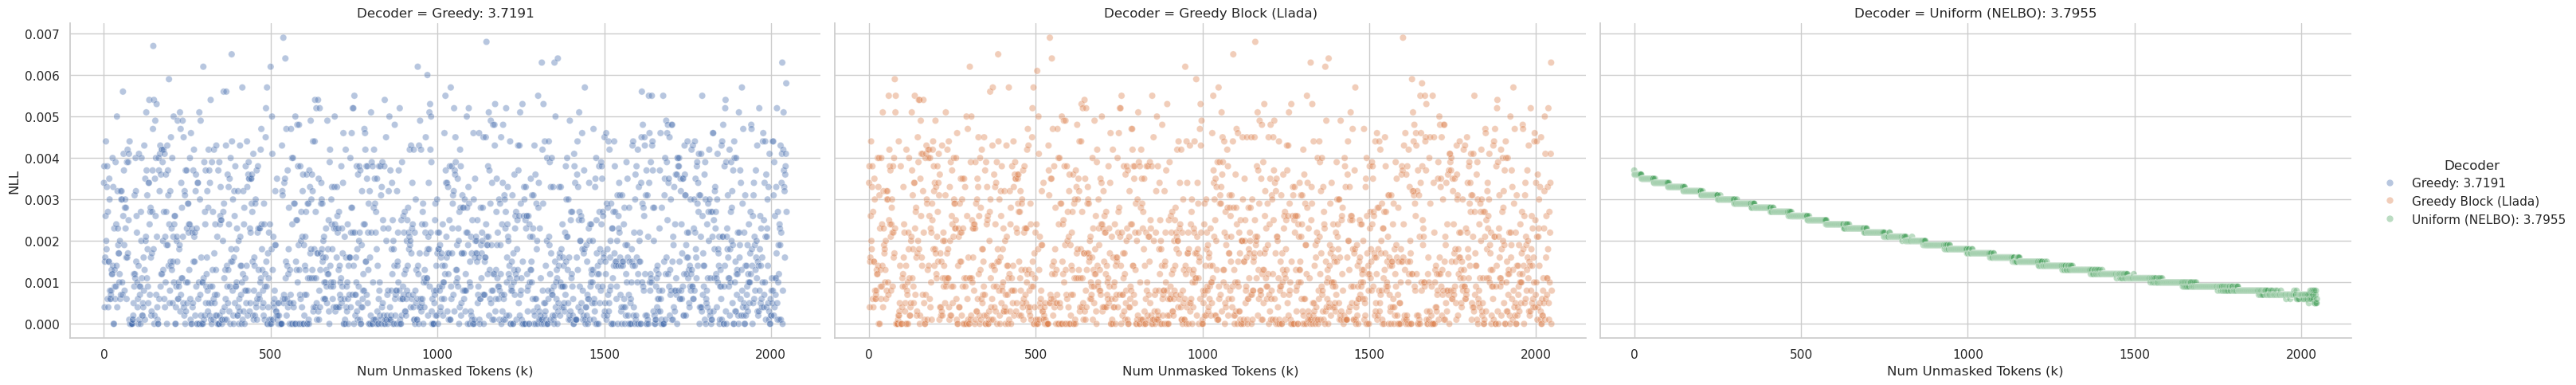

In [13]:
figure = sns.relplot(
    data=df,
    kind="scatter",
    x="Num Unmasked Tokens (k)",
    y="NLL",
    hue="Decoder",
    aspect=2,
    marker="o",
    alpha=0.4,
    col="Decoder",
)


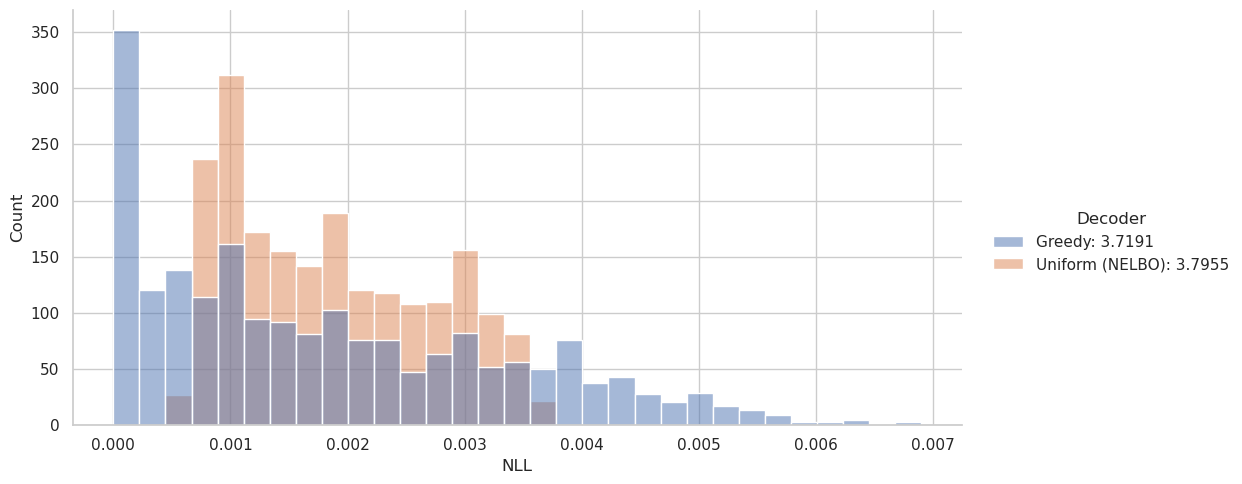

In [33]:
figure = sns.displot(
    data=df,
    kind="hist",
    x="NLL",
    hue="Decoder",
    aspect=2,
)

In [18]:
print(f"Greedy Decoding: \t\t{sum(greedy):.4f}")
print(f"Greedy-Block Decoding: \t\t{sum(greedy_block):.4f}")
print(f"Unifiorm Decoding: \t\t{sum(uniform):.4f}")

Greedy Decoding: 		3.7191
Greedy-Block Decoding: 		3.7242
Unifiorm Decoding: 		3.7955
